# Lab : Image Classification using Convolutional Neural Networks

At the end of this laboratory, you would get familiarized with

*   Creating deep networks using Keras
*   Steps necessary in training a neural network
*   Prediction and performance analysis using neural networks

---

# **In case you use a colaboratory environment**
By default, Colab notebooks run on CPU.
You can switch your notebook to run with GPU.

In order to obtain access to the GPU, you need to choose the tab Runtime and then select “Change runtime type” as shown in the following figure:

![Changing runtime](https://miro.medium.com/max/747/1*euE7nGZ0uJQcgvkpgvkoQg.png)

When a pop-up window appears select GPU. Ensure “Hardware accelerator” is set to GPU.

# **Working with a new dataset: CIFAR-10**

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. More information about CIFAR-10 can be found [here](https://www.cs.toronto.edu/~kriz/cifar.html).

In Keras, the CIFAR-10 dataset is also preloaded in the form of four Numpy arrays. x_train and y_train contain the training set, while x_test and y_test contain the test data. The images are encoded as Numpy arrays and their corresponding labels ranging from 0 to 9.

Your task is to:

*   Visualize the images in CIFAR-10 dataset. Create a 10 x 10 plot showing 10 random samples from each class.
*   Convert the labels to one-hot encoded form.
*   Normalize the images.




In [18]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from keras.backend import clear_session

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2199s 13us/step


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

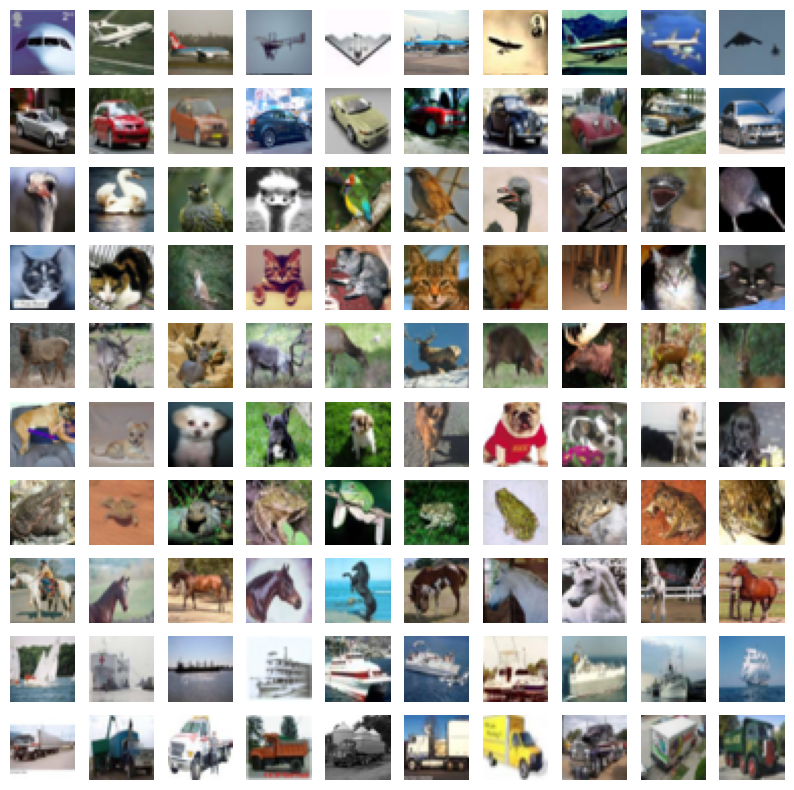

In [2]:
fig, axes = plt.subplots(10, 10, figsize=(10, 10))
for label in range(10):
    idx = np.where(y_train.flatten() == label)[0]      # positions of this class
    chosen = np.random.choice(idx, 10, replace=False)  # 10 at random
    for j, i in enumerate(chosen):
        axes[label, j].imshow(x_train[i])
        axes[label, j].axis("off")
plt.show()

In [3]:
y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)
x_train = x_train / 255.0
x_test  = x_test / 255.0

## Define the following model (same as the one in tutorial)

For the convolutional front-end, start with a single convolutional layer with a small filter size (3,3) and a modest number of filters (32) followed by a max pooling layer. 

Use the input as (32,32,3). 

The filter maps can then be flattened to provide features to the classifier. 

Use a dense layer with 100 units before the classification layer (which is also a dense layer with softmax activation).

In [4]:
from keras.backend import clear_session
clear_session()

In [7]:
clear_session()
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(100, activation="relu"),
    Dense(10, activation="softmax")
])
model.summary()

/opt/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       720,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 722,006 (2.75 MB)

 Trainable params: 722,006 (2.75 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

 *   Plot the cross entropy loss curve and the accuracy curve

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.1885 - loss: 2.2065 - val_accuracy: 0.2455 - val_loss: 2.1255
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.2698 - loss: 2.0693 - val_accuracy: 0.2909 - val_loss: 2.0182
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.3084 - loss: 1.9805 - val_accuracy: 0.3018 - val_loss: 1.9609
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.3298 - loss: 1.9211 - val_accuracy: 0.3321 - val_loss: 1.9040
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.3447 - loss: 1.8806 - val_accuracy: 0.3483 - val_loss: 1.8620
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.3559 - loss: 1.8468 - val_accuracy: 0.3627 - val_loss: 1.8264
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.3678 - loss: 1.8185 - val_accuracy: 0.3526 - val_loss: 1.8329
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.3735 - loss: 1.7960 - val_accuracy: 0.3761 - v

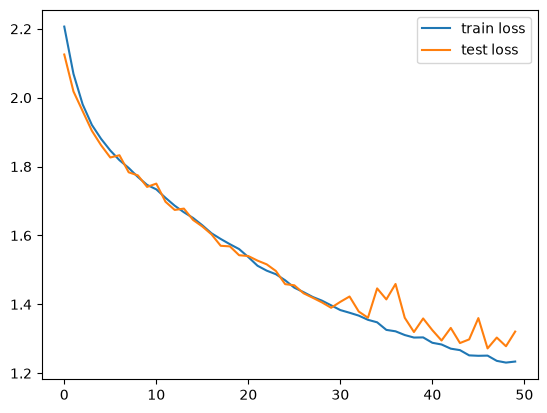

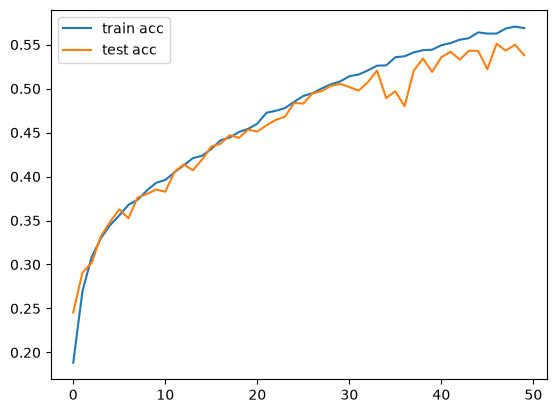

In [8]:
model.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])
history = model.fit(x_train, y_train, epochs=50, batch_size=512,
                    validation_data=(x_test, y_test))

plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="test loss")
plt.legend(); plt.show()
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="test acc")
plt.legend(); plt.show()

## Defining Deeper Architectures: VGG Models

*   Define a deeper model architecture for CIFAR-10 dataset and train the new model for 50 epochs with a batch size of 512. We will use VGG model as the architecture.

Stack two convolutional layers with 32 filters, each of 3 x 3. 

Use a max pooling layer and next flatten the output of the previous layer and add a dense layer with 128 units before the classification layer. 

For all the layers, use ReLU activation function. 

Use same padding for the layers to ensure that the height and width of each layer output matches the input


In [9]:
from keras.backend import clear_session
clear_session()

In [10]:
clear_session()
model2 = Sequential([
    Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(32, 32, 3)),
    Conv2D(32, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [11]:
model2.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])
history2 = model2.fit(x_train, y_train, epochs=50, batch_size=512,
                      validation_data=(x_test, y_test))

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 15s 152ms/step - accuracy: 0.1734 - loss: 2.2513 - val_accuracy: 0.2352 - val_loss: 2.1774
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 14s 147ms/step - accuracy: 0.2702 - loss: 2.0808 - val_accuracy: 0.2895 - val_loss: 2.0101
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 13s 136ms/step - accuracy: 0.2983 - loss: 1.9835 - val_accuracy: 0.3274 - val_loss: 1.9236
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 13s 132ms/step - accuracy: 0.3315 - loss: 1.9078 - val_accuracy: 0.3349 - val_loss: 1.9048
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 13s 131ms/step - accuracy: 0.3510 - loss: 1.8551 - val_accuracy: 0.3655 - val_loss: 1.8223
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 13s 130ms/step - accuracy: 0.3695 - loss: 1.8065 - val_accuracy: 0.3620 - val_loss: 1.7909
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step - accuracy: 0.3805 - loss: 1.7684 - val_accuracy: 0.3841 - val_loss: 1.7754
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step - accuracy: 0.3942 - loss: 1.7341 - val_accu

*   Compare the performance of both the models by plotting the loss and accuracy curves of both the training steps. Does the deeper model perform better? Comment on the observation.
 

In [15]:
history1 = history

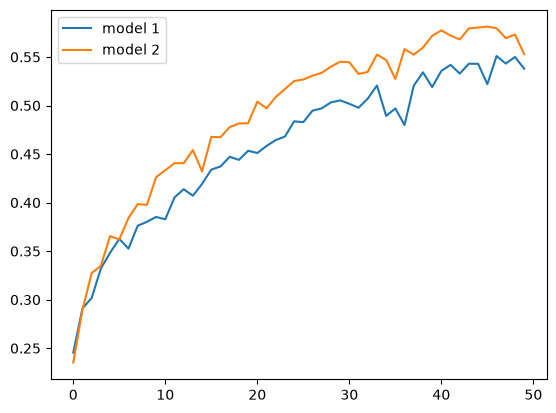

In [16]:
plt.plot(history1.history["val_accuracy"], label="model 1")
plt.plot(history2.history["val_accuracy"], label="model 2")
plt.legend(); plt.show()

**Comment on the observation**

#The deeper model reaches a higher test accuracy than the simple CNN for almost all epochs
...

*   Use predict function to predict the output for the test split
*   Plot the confusion matrix for the new model and comment on the class confusions.


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


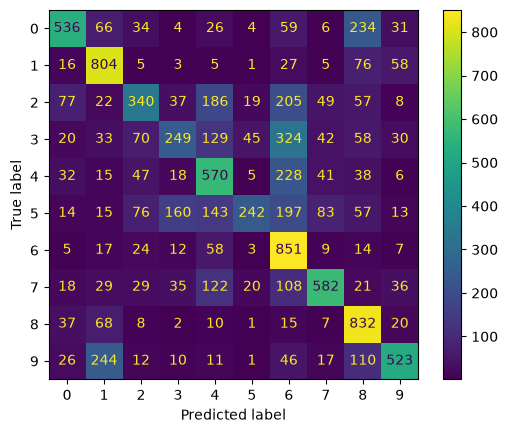

In [19]:
pred = model2.predict(x_test)                    # shape (10000, 10): probabilities
y_pred = np.argmax(pred, axis=1)            # winning class per image
y_true = np.argmax(y_test, axis=1)          # back from one-hot to a number
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()

**Comment here :**

#The model classifies frogs, ships and automobiles best, and animals such as cats, dogs and birds worst.
...

*    Print the test accuracy for the trained model.

In [21]:
loss, acc = model2.evaluate(x_test, y_test)
print("Test accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5529 - loss: 1.2751
Test accuracy: 0.5529000163078308


## Define the complete VGG architecture.

Stack two convolutional layers with 64 filters, each of 3 x 3 followed by max pooling layer. 

Stack two more convolutional layers with 128 filters, each of 3 x 3, followed by max pooling, followed by two more convolutional layers with 256 filters, each of 3 x 3, followed by max pooling. 

Flatten the output of the previous layer and add a dense layer with 128 units before the classification layer. 

For all the layers, use ReLU activation function. 

Use same padding for the layers to ensure that the height and width of each layer output matches the input

*   Change the size of input to 64 x 64.

In [15]:
from keras.backend import clear_session
clear_session()

In [22]:
x_train64 = tf.image.resize(x_train[:10000], (64, 64)).numpy()
y_train64 = y_train[:10000]
x_test64  = tf.image.resize(x_test, (64, 64)).numpy()

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 10 epochs with a batch size of 512.
*   Predict the output for the test split and plot the confusion matrix for the new model and comment on the class confusions.

In [23]:
clear_session()
model3 = Sequential([
    Conv2D(64, (3, 3), activation="relu", padding="same", input_shape=(64, 64, 3)),
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation="relu", padding="same"),
    Conv2D(128, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),
    Conv2D(256, (3, 3), activation="relu", padding="same"),
    Conv2D(256, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])
model3.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])
model3.fit(x_train64, y_train64, epochs=10, batch_size=512)

/opt/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 101s 5s/step - accuracy: 0.1065 - loss: 2.3018
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 99s 5s/step - accuracy: 0.1155 - loss: 2.3005
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 96s 5s/step - accuracy: 0.1368 - loss: 2.2993
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 103s 5s/step - accuracy: 0.1451 - loss: 2.2980
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 101s 5s/step - accuracy: 0.1422 - loss: 2.2966
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 99s 5s/step - accuracy: 0.1496 - loss: 2.2949
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 100s 5s/step - accuracy: 0.1447 - loss: 2.2930
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 104s 5s/step - accuracy: 0.1543 - loss: 2.2905
Epoch 9/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 100s 5s/step - accuracy: 0.1634 - loss: 2.2873
Epoch 10/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 99s 5s/step - accuracy: 0.1594 - loss: 2.2831


# Understanding deep networks

*   What is the use of activation functions in network? Why is it needed?
*   We have used softmax activation function in the exercise. There are other activation functions available too. What is the difference between sigmoid activation and softmax activation?
*   What is the difference between categorical crossentropy and binary crossentropy loss?

**Write the answers below :**

1 - Use of activation functions:

Without them, any number of stacked layers collapses into a single linear function

2 - Key Differences between sigmoid and softmax:

With Softmax the classes compete, so if one goes up, the others go down. You pick the biggest one. 
With Sigmoid shows a % of yes/no to determine the winner, while several clases can be true at the same time.

3 - Key Differences between categorical crossentropy and binary crossentropy loss:

Binary crossentropy is used for two classes (or independent yes/no labels) with sigmoid outputs. 
Categorical crossentropy is used for more than two mutually exclusive classes with softmax outputs and one-hot labels.